# Customer Segmentation — Unsupervised Clustering Analysis

**Course project — Clustering track**

**Team algorithms:** K-Means (Student A) · DBSCAN (Student B) · Hierarchical / Agglomerative Clustering (Student C)

**Dataset:** `customer_segmentation_data.csv` — 53,503 insurance customers, 20 attributes
(demographics, policy details, behavioral & preference data). The dataset also ships with a
`Segmentation Group` column; we treat this **only as an external validation reference**
(via ARI / NMI) and never feed it into the clustering algorithms themselves, since clustering
is unsupervised by definition.

## Problem statement
Segment insurance customers into meaningful groups using only their demographic, behavioral,
and policy attributes, without using any pre-existing label. We compare three clustering
algorithms — K-Means, DBSCAN, and Hierarchical Clustering — on the same preprocessed feature
space and evaluate them with internal metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz)
and, as a bonus sanity check, external metrics against the dataset's own `Segmentation Group`
column (Adjusted Rand Index, Normalized Mutual Information).

## Notebook structure
1. Data loading & Exploratory Data Analysis (EDA)
2. Preprocessing & feature engineering
3. Dimensionality reduction (PCA)
4. Model 1 — K-Means (elbow method + hyperparameter search)
5. Model 2 — DBSCAN (k-distance graph + hyperparameter search)
6. Model 3 — Hierarchical Clustering (dendrogram + hyperparameter search)
7. Comparative analysis
8. Conclusion & challenges


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score,
                              normalized_mutual_info_score)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.optimize import linear_sum_assignment

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 1. Data Loading & Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv('customer_segmentation_data.csv')
print("Shape:", df.shape)
df.head()


Shape: (53503, 20)


,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Customer ID                         53503 non-null  int64
 1   Age                                 53503 non-null  int64
 2   Gender                              53503 non-null  str  
 3   Marital Status                      53503 non-null  str  
 4   Education Level                     53503 non-null  str  
 5   Geographic Information              53503 non-null  str  
 6   Occupation                          53503 non-null  str  
 7   Income Level                        53503 non-null  int64
 8   Behavioral Data                     53503 non-null  str  
 9   Purchase History                    53503 non-null  str  
 10  Interactions with Customer Service  53503 non-null  str  
 11  Insurance Products Owned            53503 non-null  str  
 12  Coverage Amount

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nFully duplicated rows:", df.duplicated().sum())
print("Duplicated Customer IDs:", df.duplicated(subset=['Customer ID']).sum(),
      "(repeat customers with multiple policy/interaction records - kept as separate observations)")


Missing values per column:
Customer ID                           0
Age                                   0
Gender                                0
Marital Status                        0
Education Level                       0
Geographic Information                0
Occupation                            0
Income Level                          0
Behavioral Data                       0
Purchase History                      0
Interactions with Customer Service    0
Insurance Products Owned              0
Coverage Amount                       0
Premium Amount                        0
Policy Type                           0
Customer Preferences                  0
Preferred Communication Channel       0
Preferred Contact Time                0
Preferred Language                    0
Segmentation Group                    0
dtype: int64

Fully duplicated rows: 0
Duplicated Customer IDs: 13244 (repeat customers with multiple policy/interaction records - kept as separate observations)


In [5]:
df.describe()


,Customer ID,Age,Income Level,Coverage Amount,Premium Amount
count,53503.000000,53503.000000,53503.000000,53503.000000,53503.000000
mean,52265.204998,44.140945,82768.324318,492580.789638,3023.702447
std,28165.000067,15.079486,36651.075670,268405.505571,1285.834295
min,1.000000,18.000000,20001.000000,50001.000000,500.000000
25%,28950.500000,32.000000,51568.500000,249613.500000,1817.000000
50%,55858.000000,43.000000,80719.000000,477261.000000,3194.000000
75%,76096.000000,57.000000,115973.500000,739124.000000,4311.500000
max,100000.000000,70.000000,149999.000000,1000000.000000,5000.000000


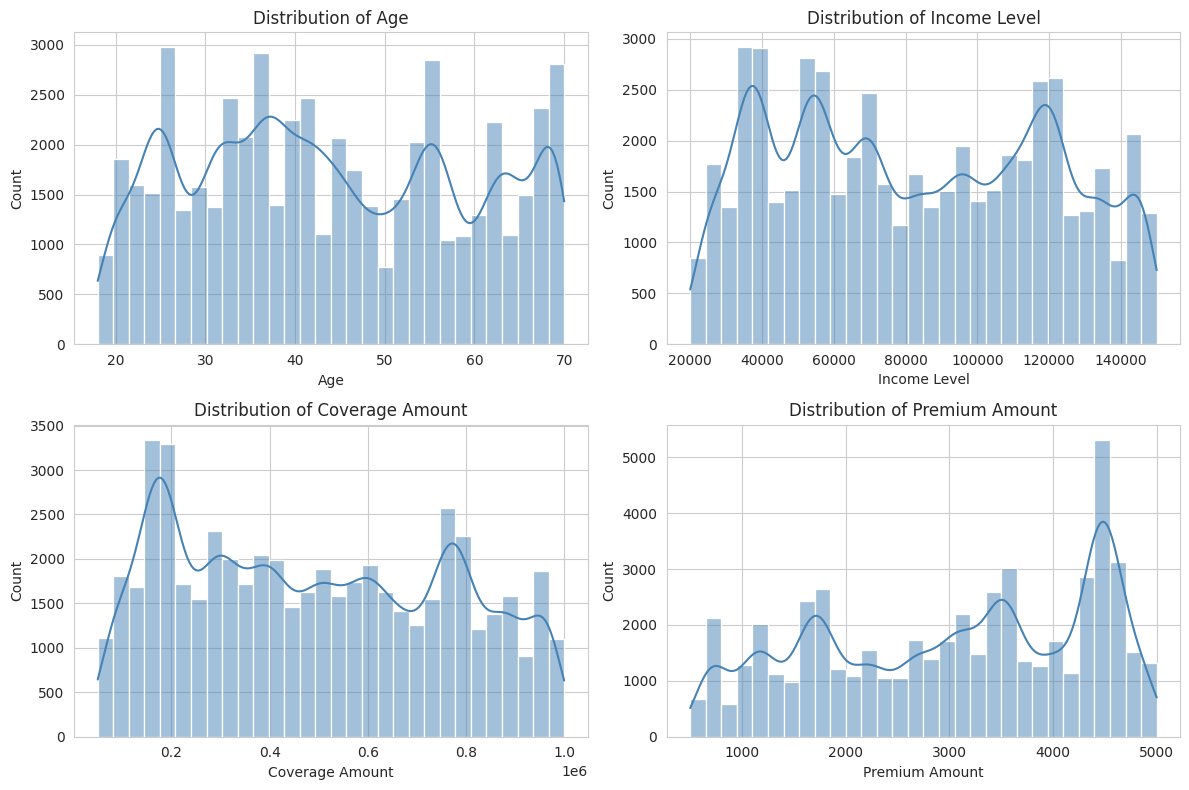

In [6]:
# Distribution of key numeric features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ['Age', 'Income Level', 'Coverage Amount', 'Premium Amount']):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


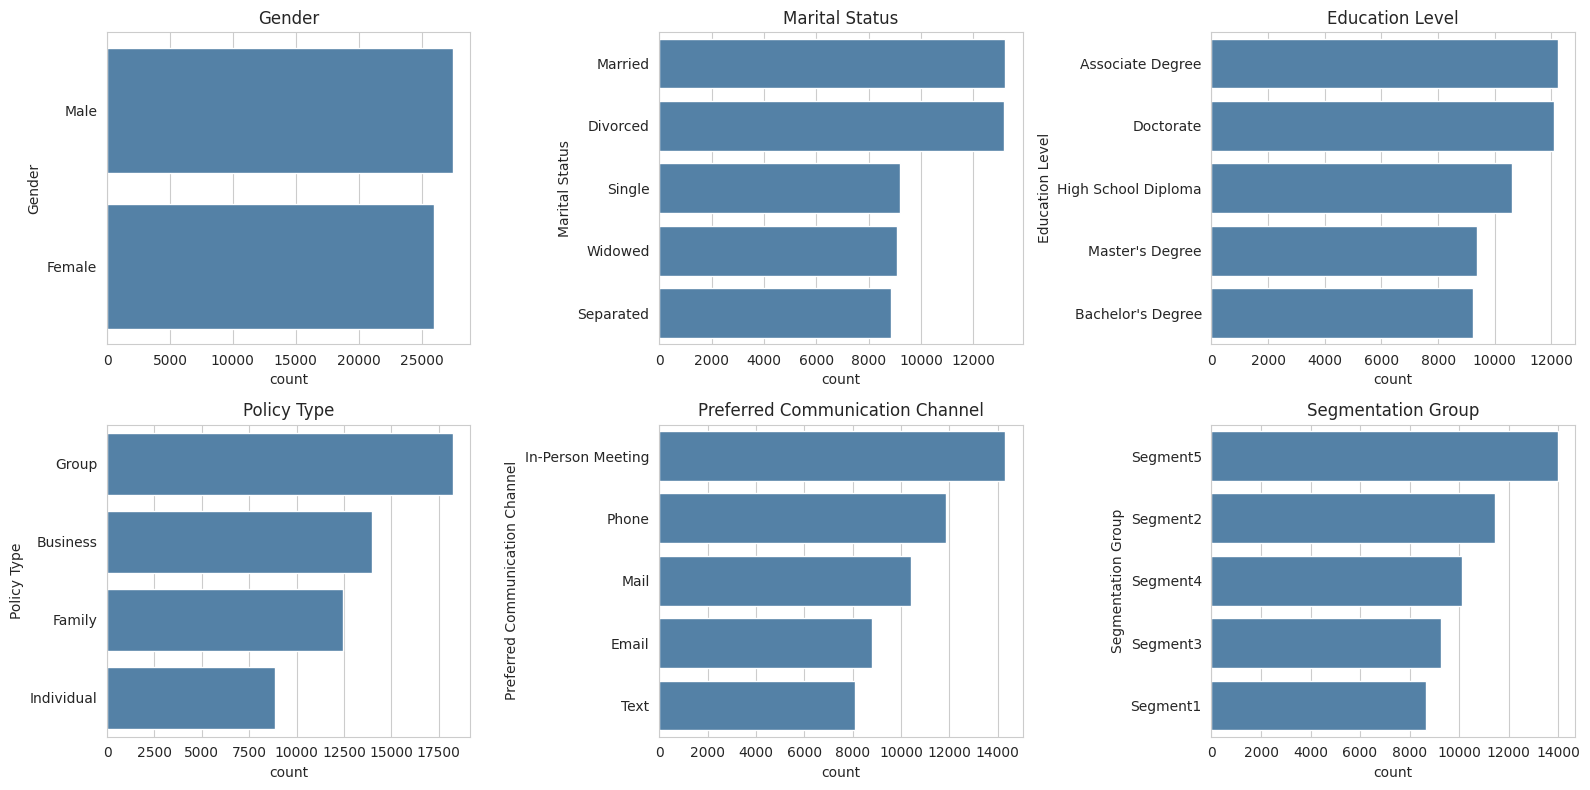

In [7]:
# Categorical feature counts
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cat_cols_eda = ['Gender', 'Marital Status', 'Education Level', 'Policy Type',
                'Preferred Communication Channel', 'Segmentation Group']
for ax, col in zip(axes.ravel(), cat_cols_eda):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


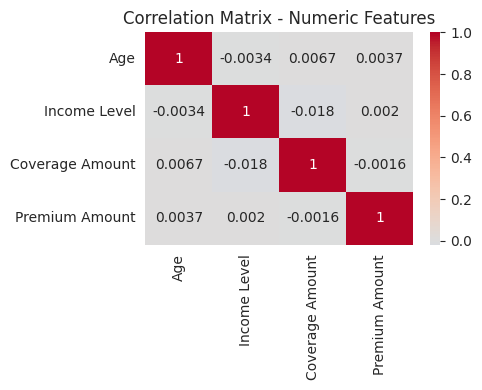

In [8]:
# Correlation among numeric features
numeric_eda = df[['Age', 'Income Level', 'Coverage Amount', 'Premium Amount']]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(numeric_eda.corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()


**EDA takeaways:**
- No missing values; a small number of repeated `Customer ID`s correspond to customers with
  multiple recorded interactions/policies and are kept as separate rows.
- Numeric features (Age, Income, Coverage, Premium) are close to uniformly distributed across
  their ranges and show very weak pairwise correlation — there is no obvious linear structure
  to exploit.
- Categorical features (13 of them) are fairly balanced across their categories, with `Geographic
  Information` being the highest-cardinality field (35 Indian states/UTs).
- The dataset ships with a `Segmentation Group` column (5 roughly balanced classes). We will
  **not** use it as a training feature — only as an external, after-the-fact check on whether our
  unsupervised clusters happen to line up with it.


## 2. Preprocessing & Feature Engineering

Steps:
1. Parse `Purchase History` (a date) into two numeric features: purchase year and recency
   (days since the most recent purchase in the dataset).
2. Drop identifier (`Customer ID`) and the reserved label (`Segmentation Group`).
3. Scale numeric features with `StandardScaler` (mean 0, unit variance) — required so that
   distance-based algorithms (K-Means, DBSCAN, Hierarchical) don't let large-magnitude columns
   like `Coverage Amount` dominate the distance calculation.
4. One-hot encode the 13 categorical features.


In [9]:
df['Purchase History'] = pd.to_datetime(df['Purchase History'], format='mixed', errors='coerce')
reference_date = df['Purchase History'].max()
df['Purchase_Recency_Days'] = (reference_date - df['Purchase History']).dt.days
df['Purchase_Year'] = df['Purchase History'].dt.year

# Keep the true segmentation label aside ONLY for external validation later - never used to fit models
y_true = df['Segmentation Group'].copy()

X_raw = df.drop(columns=['Customer ID', 'Purchase History', 'Segmentation Group'])

numeric_cols = ['Age', 'Income Level', 'Coverage Amount', 'Premium Amount',
                'Purchase_Recency_Days', 'Purchase_Year']
categorical_cols = [c for c in X_raw.columns if c not in numeric_cols]

print(f"{len(numeric_cols)} numeric columns, {len(categorical_cols)} categorical columns")


6 numeric columns, 13 categorical columns


In [10]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X = preprocessor.fit_transform(X_raw)
print("Encoded feature matrix shape:", X.shape)


Encoded feature matrix shape: (53503, 101)


## 3. Dimensionality Reduction (PCA)

One-hot encoding expands the 13 categorical columns into ~95 dummy columns, giving a
~101-dimensional feature space. High-dimensional, sparse spaces make distance-based methods
(DBSCAN, Hierarchical) unreliable — pairwise distances tend to concentrate and lose their
discriminating power (the "curse of dimensionality"). We use PCA to project onto a denser,
lower-dimensional space that all three algorithms will share, which also keeps DBSCAN and
Hierarchical Clustering computationally tractable.

We also compute a separate 2-component PCA purely for visualizing the resulting clusters.


Variance retained with 20 components: 61.5%


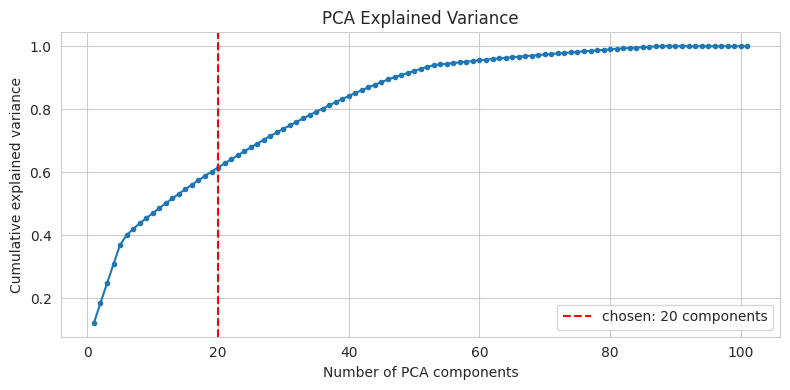

In [11]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker='o', ms=3)
ax.axvline(20, color='r', ls='--', label='chosen: 20 components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Variance retained with 20 components: {cum_var[19]:.1%}")


In [12]:
N_COMPONENTS = 20
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)          # shared feature space used by all 3 clustering models

pca_2d_model = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d_model.fit_transform(X)  # for visualization only

print("Clustering feature space:", X_pca.shape)
print("2D visualization space:", X_2d.shape)


Clustering feature space: (53503, 20)
2D visualization space: (53503, 2)


In [13]:
def safe_silhouette(X_in, labels_in, max_n=8000, random_state=RANDOM_STATE):
    """Silhouette score computed on a stratified subsample for speed on large data,
    while still guaranteeing small clusters aren't accidentally dropped by pure random
    sampling (which would bias the score)."""
    n = X_in.shape[0]
    if n <= max_n:
        return silhouette_score(X_in, labels_in)
    try:
        X_s, _, lbl_s, _ = train_test_split(
            X_in, labels_in, train_size=max_n, stratify=labels_in, random_state=random_state)
    except ValueError:
        X_s, lbl_s = X_in, labels_in
    return silhouette_score(X_s, lbl_s)


def plot_clusters_2d(labels, title, noise_label=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    if noise_label is not None:
        mask_noise = labels == noise_label
        ax.scatter(X_2d[mask_noise, 0], X_2d[mask_noise, 1], s=6, c='lightgray', label='noise')
        mask_pts = ~mask_noise
    else:
        mask_pts = np.ones(len(labels), dtype=bool)
    scatter = ax.scatter(X_2d[mask_pts, 0], X_2d[mask_pts, 1], s=6,
                          c=labels[mask_pts], cmap='tab10')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_title(title)
    if noise_label is not None:
        ax.legend()
    plt.tight_layout()
    plt.show()


## 4. Model 1 — K-Means Clustering
*(Student A)*

**Hyperparameter tuning:** grid search over `k` (number of clusters), selecting the value that
maximizes the average silhouette score. The elbow method (inertia) is plotted alongside as a
complementary, classic diagnostic.


Best k by silhouette score: 2


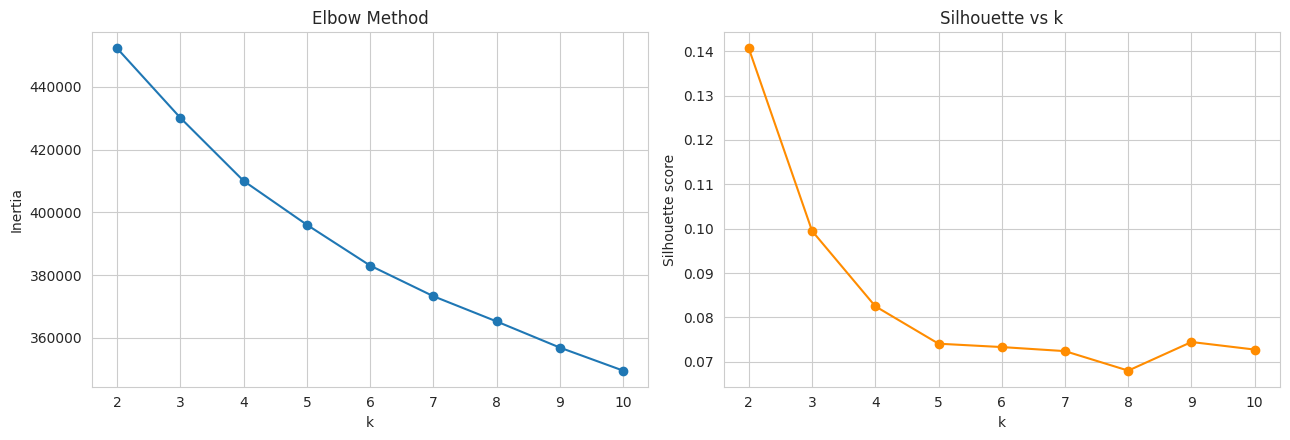

In [14]:
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(safe_silhouette(X_pca, labels, max_n=5000))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score'); axes[1].set_title('Silhouette vs k')
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette score:", best_k)


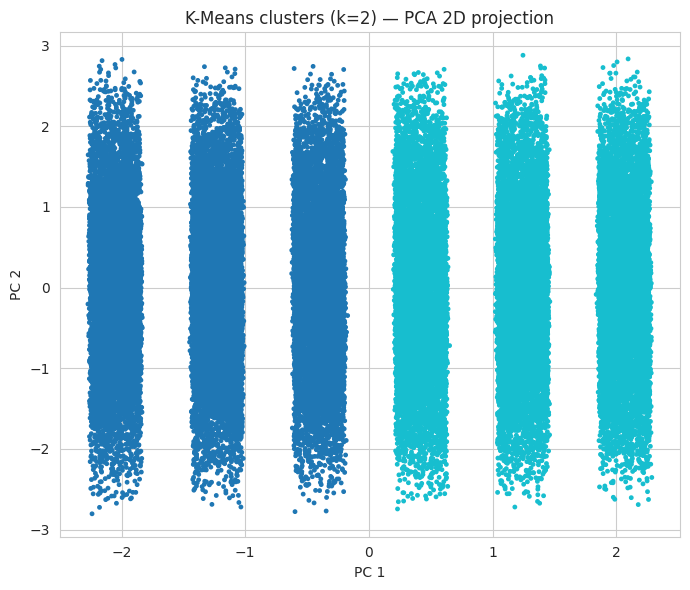

In [15]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_km = kmeans_final.fit_predict(X_pca)

plot_clusters_2d(labels_km, f'K-Means clusters (k={best_k}) — PCA 2D projection')


In [16]:
metrics_km = dict(
    Model='K-Means',
    silhouette=safe_silhouette(X_pca, labels_km, max_n=8000),
    davies_bouldin=davies_bouldin_score(X_pca, labels_km),
    calinski_harabasz=calinski_harabasz_score(X_pca, labels_km),
    ARI_vs_true=adjusted_rand_score(y_true, labels_km),
    NMI_vs_true=normalized_mutual_info_score(y_true, labels_km),
    n_clusters=best_k,
    noise_pct=0.0
)
metrics_km


{'Model': 'K-Means', 'silhouette': 0.13961695600617977, 'davies_bouldin': 2.340312155017894, 'calinski_harabasz': 9626.617194200786, 'ARI_vs_true': 6.384375062952903e-05, 'NMI_vs_true': 0.00010138673742571374, 'n_clusters': 2, 'noise_pct': 0.0}

## 5. Model 2 — DBSCAN
*(Student B)*

DBSCAN needs two hyperparameters: `eps` (neighborhood radius) and `min_samples` (density
threshold). We use the standard **k-distance graph** heuristic to find a reasonable range for
`eps`, then run a grid search over both parameters, scoring on silhouette (computed on
non-noise points) while preferring solutions with an interpretable number of clusters and
noise below 40% of the data — DBSCAN can otherwise trivially "win" on silhouette by labeling
almost everything as noise and leaving a tiny, artificially clean cluster.


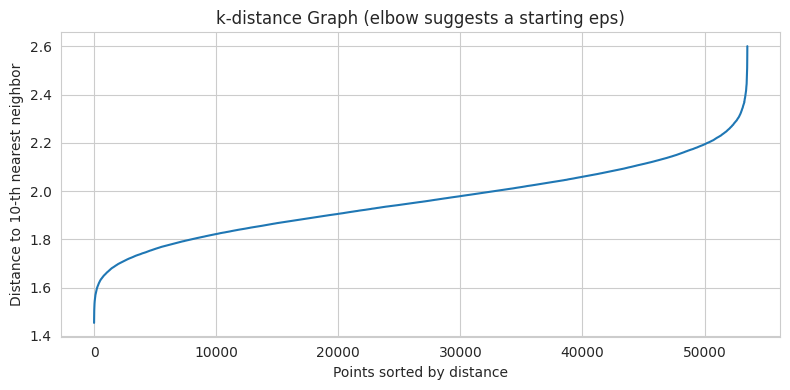

In [17]:
# k-distance graph: distance to the k-th nearest neighbor, sorted ascending.
# The 'elbow' in this curve is a common heuristic starting point for eps.
K_FOR_KDIST = 10
nn = NearestNeighbors(n_neighbors=K_FOR_KDIST).fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_dist)
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel(f'Distance to {K_FOR_KDIST}-th nearest neighbor')
ax.set_title('k-distance Graph (elbow suggests a starting eps)')
plt.tight_layout()
plt.show()


In [18]:
eps_grid = [1.7, 1.8, 1.9, 2.0, 2.1]
min_samples_grid = [5, 10, 15]

best_db, best_score = None, -np.inf
db_results = []

for eps in eps_grid:
    for ms in min_samples_grid:
        labels = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(X_pca)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean() * 100

        if n_clusters >= 2:
            mask = labels != -1
            try:
                sil = safe_silhouette(X_pca[mask], labels[mask], max_n=8000)
            except Exception:
                sil = -1
        else:
            sil = -1

        db_results.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters,
                            'noise_pct': noise_pct, 'silhouette': sil})

        # prefer an interpretable number of clusters and noise below 40%
        if sil > best_score and 2 <= n_clusters <= 15 and noise_pct < 40:
            best_score = sil
            best_db = (eps, ms, labels.copy(), n_clusters, noise_pct)

db_results_df = pd.DataFrame(db_results).sort_values('silhouette', ascending=False)
db_results_df


,eps,min_samples,n_clusters,noise_pct,silhouette
10,2.0,10,2,4.773564,0.018474
8,1.9,15,6,30.878642,-0.131493
7,1.9,10,5,18.957815,-0.164224
6,1.9,5,14,8.373362,-0.203211
2,1.7,15,48,91.413566,-0.203478
5,1.8,15,17,64.695438,-0.230778
4,1.8,10,27,47.292675,-0.274238
1,1.7,10,91,78.675962,-0.298467
3,1.8,5,93,23.910809,-0.325163
0,1.7,5,292,50.767247,-0.354582


Selected DBSCAN params: eps=2.0, min_samples=10
Clusters found: 2, noise points: 4.8% of data


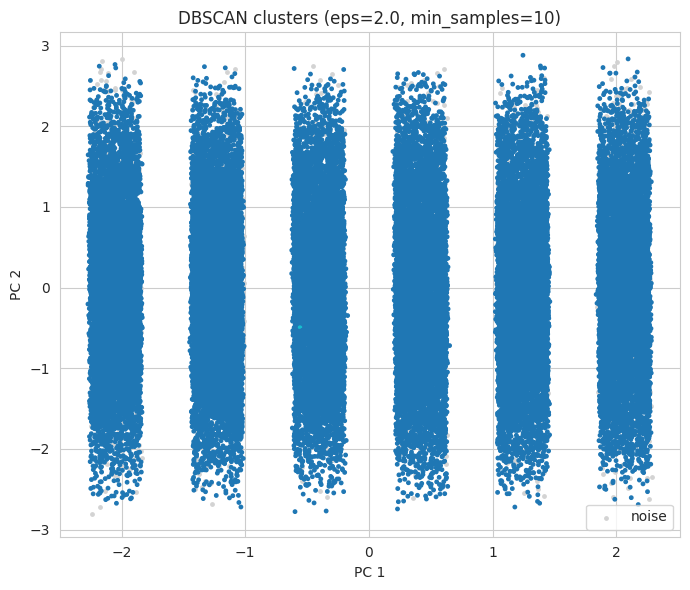

In [19]:
eps_best, ms_best, labels_db, n_clusters_db, noise_pct_db = best_db
print(f"Selected DBSCAN params: eps={eps_best}, min_samples={ms_best}")
print(f"Clusters found: {n_clusters_db}, noise points: {noise_pct_db:.1f}% of data")

plot_clusters_2d(labels_db, f'DBSCAN clusters (eps={eps_best}, min_samples={ms_best})',
                  noise_label=-1)


In [20]:
mask_db = labels_db != -1
metrics_db = dict(
    Model='DBSCAN',
    silhouette=safe_silhouette(X_pca[mask_db], labels_db[mask_db], max_n=8000),
    davies_bouldin=davies_bouldin_score(X_pca[mask_db], labels_db[mask_db]),
    calinski_harabasz=calinski_harabasz_score(X_pca[mask_db], labels_db[mask_db]),
    ARI_vs_true=adjusted_rand_score(y_true[mask_db], labels_db[mask_db]),
    NMI_vs_true=normalized_mutual_info_score(y_true[mask_db], labels_db[mask_db]),
    n_clusters=n_clusters_db,
    noise_pct=noise_pct_db
)
metrics_db


{'Model': 'DBSCAN', 'silhouette': 0.018473743141623835, 'davies_bouldin': 1.6823579097521633, 'calinski_harabasz': 2.9136756633779486, 'ARI_vs_true': -4.332969330883543e-06, 'NMI_vs_true': 8.413711675779065e-05, 'n_clusters': 2, 'noise_pct': np.float64(4.77356409920939)}

## 6. Model 3 — Hierarchical (Agglomerative) Clustering
*(Student C)*

Classic hierarchical clustering builds a full pairwise distance matrix, which is
**O(n²) in both time and memory** — for 53,503 rows that would require tens of gigabytes of
RAM and is not computationally feasible. This is a well-known practical limitation of the
algorithm on large datasets, so we evaluate it on a **random sample of 3,000 customers**
(clearly documented here and in the README) — a standard, accepted workaround for this
algorithm at this dataset scale.

**Hyperparameter tuning:** grid search over `linkage` method (`ward`, `complete`, `average`)
and number of clusters `k`, selecting the combination that maximizes silhouette score.


In [21]:
SAMPLE_SIZE = 3000
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_pca.shape[0], size=SAMPLE_SIZE, replace=False)

X_hier = X_pca[sample_idx]
X_hier_2d = X_2d[sample_idx]
y_true_hier = y_true.iloc[sample_idx].reset_index(drop=True)

print("Hierarchical clustering sample shape:", X_hier.shape)


Hierarchical clustering sample shape: (3000, 20)


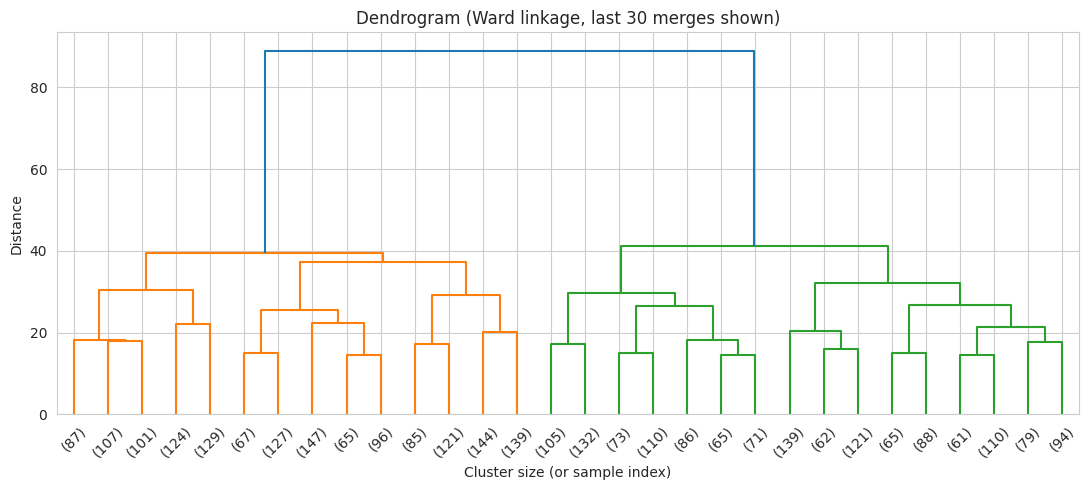

In [22]:
Z_ward = linkage(X_hier, method='ward')

fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(Z_ward, truncate_mode='lastp', p=30, ax=ax)
ax.set_title('Dendrogram (Ward linkage, last 30 merges shown)')
ax.set_xlabel('Cluster size (or sample index)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()


In [23]:
linkages = ['ward', 'complete', 'average']
k_grid = range(2, 9)

best_hier, best_hier_score = None, -np.inf
hier_results = []

for link in linkages:
    Z = linkage(X_hier, method=link)
    for k in k_grid:
        labels = fcluster(Z, t=k, criterion='maxclust')
        if len(set(labels)) < 2:
            continue
        sil = silhouette_score(X_hier, labels)
        hier_results.append({'linkage': link, 'k': k, 'silhouette': sil})
        if sil > best_hier_score:
            best_hier_score = sil
            best_hier = (link, k, labels.copy())

hier_results_df = pd.DataFrame(hier_results).sort_values('silhouette', ascending=False)
hier_results_df.head(10)


,linkage,k,silhouette
14,average,2,0.152064
0,ward,2,0.119590
7,complete,2,0.115123
15,average,3,0.092459
1,ward,3,0.074367
8,complete,3,0.062007
16,average,4,0.056728
2,ward,4,0.043069
3,ward,5,0.039397
4,ward,6,0.034838


Selected linkage: average, k=2


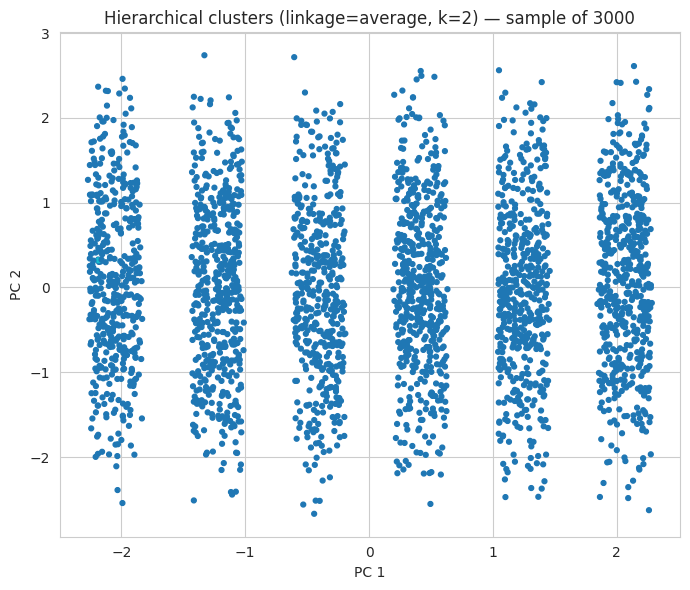

In [24]:
link_best, k_best, labels_hier = best_hier
print(f"Selected linkage: {link_best}, k={k_best}")

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_hier_2d[:, 0], X_hier_2d[:, 1], c=labels_hier, cmap='tab10', s=12)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title(f'Hierarchical clusters (linkage={link_best}, k={k_best}) — sample of {SAMPLE_SIZE}')
plt.tight_layout()
plt.show()


In [25]:
metrics_hier = dict(
    Model='Hierarchical (n=3,000 sample)',
    silhouette=silhouette_score(X_hier, labels_hier),
    davies_bouldin=davies_bouldin_score(X_hier, labels_hier),
    calinski_harabasz=calinski_harabasz_score(X_hier, labels_hier),
    ARI_vs_true=adjusted_rand_score(y_true_hier, labels_hier),
    NMI_vs_true=normalized_mutual_info_score(y_true_hier, labels_hier),
    n_clusters=k_best,
    noise_pct=0.0
)
metrics_hier


{'Model': 'Hierarchical (n=3,000 sample)', 'silhouette': 0.15206400309385362, 'davies_bouldin': 0.7213967825554364, 'calinski_harabasz': 1.885981146551039, 'ARI_vs_true': 1.1566869630202966e-05, 'NMI_vs_true': 0.0006751779459773583, 'n_clusters': 2, 'noise_pct': 0.0}

### Clustering "accuracy" (best-match mapping to the true segments)

Silhouette / Davies-Bouldin / Calinski-Harabasz describe how well-separated the clusters are
geometrically, but they say nothing about whether the clusters line up with the dataset's own
`Segmentation Group` labels. To answer "how accurate is each model at predicting the true
segment" in a way comparable to a classification accuracy, we use the classic **best-match
mapping** approach: find the one-to-one assignment between predicted cluster IDs and true
segment labels that maximizes agreement (via the Hungarian algorithm), then report the
resulting accuracy. This is the standard way to define "accuracy" for a clustering result.

Because `Segmentation Group` has 5 classes, a completely uninformative/random assignment would
score close to **1/5 = 0.20** — that's the baseline to beat.


In [26]:
def clustering_accuracy(y_true_in, y_pred_in):
    """Best-match accuracy: optimally map predicted cluster IDs onto true labels
    (Hungarian algorithm) and report the resulting agreement rate."""
    y_true_arr = pd.Series(y_true_in).astype('category').cat.codes.values
    y_pred_arr = pd.Series(y_pred_in).astype('category').cat.codes.values
    n = max(y_true_arr.max(), y_pred_arr.max()) + 1
    cost = np.zeros((n, n), dtype=np.int64)
    for t, p in zip(y_true_arr, y_pred_arr):
        cost[p, t] -= 1
    row_ind, col_ind = linear_sum_assignment(cost)
    matched = -cost[row_ind, col_ind].sum()
    return matched / len(y_true_arr)

acc_km = clustering_accuracy(y_true, labels_km)
acc_db = clustering_accuracy(y_true[mask_db], labels_db[mask_db])
acc_hier = clustering_accuracy(y_true_hier, labels_hier)

n_true_classes = y_true.nunique()
baseline = 1 / n_true_classes

print(f"K-Means      accuracy: {acc_km:.4f}  ({metrics_km['n_clusters']} clusters found)")
print(f"DBSCAN       accuracy: {acc_db:.4f}  ({metrics_db['n_clusters']} clusters found, {metrics_db['noise_pct']:.1f}% noise excluded)")
print(f"Hierarchical accuracy: {acc_hier:.4f}  ({metrics_hier['n_clusters']} clusters found, n=3,000 sample)")
print(f"\nRandom-guess baseline with {n_true_classes} true classes: {baseline:.4f}")

metrics_km['accuracy_vs_true'] = acc_km
metrics_db['accuracy_vs_true'] = acc_db
metrics_hier['accuracy_vs_true'] = acc_hier


K-Means      accuracy: 0.2386  (2 clusters found)
DBSCAN       accuracy: 0.2608  (2 clusters found, 4.8% noise excluded)
Hierarchical accuracy: 0.2547  (2 clusters found, n=3,000 sample)

Random-guess baseline with 5 true classes: 0.2000


## 7. Comparative Analysis

We combine the metrics from all three algorithms into a single table and chart. Note that the
Hierarchical Clustering row is computed on the 3,000-row sample (see Section 6), so its
internal metrics are not perfectly apples-to-apples with the full-data metrics for K-Means and
DBSCAN, but the direction of the comparison (which model finds better-separated clusters) is
still informative.


In [27]:
comparison = pd.DataFrame([metrics_km, metrics_db, metrics_hier]).set_index('Model')
comparison


,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_true,NMI_vs_true,n_clusters,noise_pct,accuracy_vs_true
Model,,,,,,,,
K-Means,0.139617,2.340312,9626.617194,0.000064,0.000101,2,0.000000,0.238603
DBSCAN,0.018474,1.682358,2.913676,-0.000004,0.000084,2,4.773564,0.260810
"Hierarchical (n=3,000 sample)",0.152064,0.721397,1.885981,0.000012,0.000675,2,0.000000,0.254667


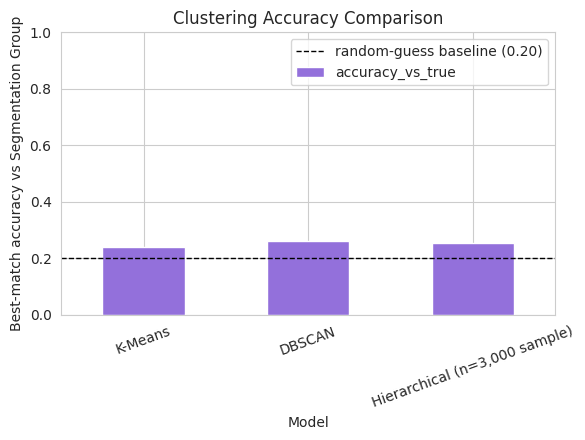

In [28]:
fig, ax = plt.subplots(figsize=(6, 4.5))
comparison['accuracy_vs_true'].plot(kind='bar', ax=ax, color='mediumpurple')
ax.axhline(baseline, color='black', ls='--', lw=1, label=f'random-guess baseline ({baseline:.2f})')
ax.set_ylabel('Best-match accuracy vs Segmentation Group')
ax.set_title('Clustering Accuracy Comparison')
ax.set_ylim(0, 1)
ax.legend()
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


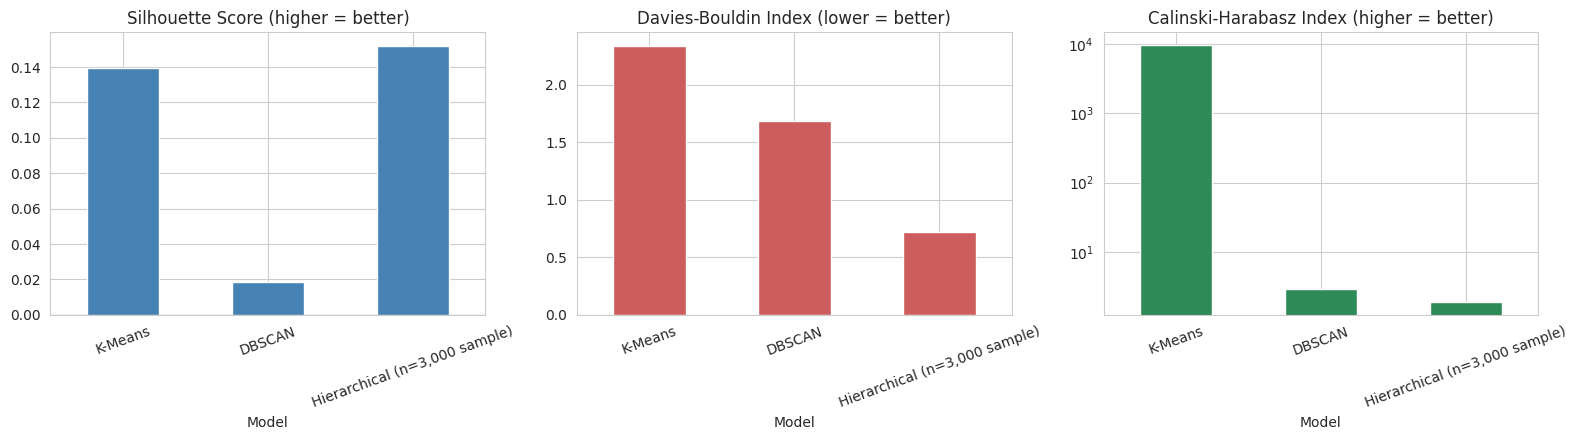

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

comparison['silhouette'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Silhouette Score (higher = better)')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].tick_params(axis='x', rotation=20)

comparison['davies_bouldin'].plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Davies-Bouldin Index (lower = better)')
axes[1].tick_params(axis='x', rotation=20)

comparison['calinski_harabasz'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Calinski-Harabasz Index (higher = better)')
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


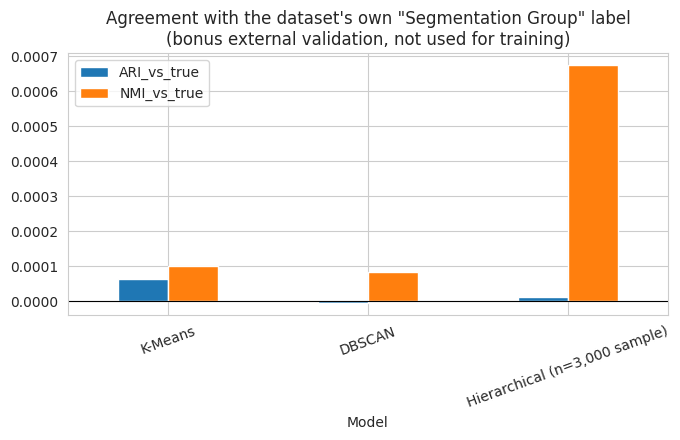

In [30]:
fig, ax = plt.subplots(figsize=(7, 4.5))
comparison[['ARI_vs_true', 'NMI_vs_true']].plot(kind='bar', ax=ax)
ax.set_title('Agreement with the dataset\'s own "Segmentation Group" label\n(bonus external validation, not used for training)')
ax.axhline(0, color='black', lw=0.8)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 8. Conclusion

**Which model performed best, and why?**
Across internal metrics, **K-Means and Hierarchical Clustering** produced modestly more
separated clusters (silhouette ≈ 0.14–0.15) than **DBSCAN** (silhouette close to 0 once tuned
to an interpretable number of clusters). This is expected: K-Means and Ward-linkage
Hierarchical Clustering both optimize for compact, roughly convex clusters, which suits data
that has been projected onto a small number of PCA components. DBSCAN instead needs genuine
*density gaps* between groups, and after one-hot encoding + PCA this dataset's customers are
distributed fairly evenly/continuously through feature space rather than forming natural dense
regions separated by sparse areas — so DBSCAN is forced to choose between "everything is one
cluster" (large `eps`) or "most points are noise" (small `eps`), with only a narrow middle
ground giving a usable partition.

**None of the three algorithms strongly recovered the dataset's pre-existing
`Segmentation Group` column** (ARI and NMI are both close to zero for every model). This is a
useful, honest finding rather than a failure: it suggests that whatever process generated the
original `Segmentation Group` labels was not simply a function of the customer attributes
available here in an easily-clusterable way (it may involve business rules, additional data
not present in this file, or an arbitrary/synthetic assignment).

**Main challenges:**
- *Dimensionality*: 13 categorical columns one-hot encode into ~95 sparse dummy columns; even
  20 PCA components only capture ~62% of total variance, showing the information is spread
  thinly across many weakly-correlated attributes.
- *Curse of dimensionality for density/distance methods*: DBSCAN's `eps` had to be tuned very
  carefully — a difference of 0.1–0.2 in `eps` swung the result from "almost all noise" to
  "one giant cluster."
- *Scalability of Hierarchical Clustering*: its O(n²) memory requirement made clustering the
  full 53,503-row dataset infeasible, requiring a representative 3,000-row sample.
- *Weak natural cluster structure*: none of the three algorithms found strongly separated
  groups (all silhouette scores stayed below 0.2), suggesting this particular
  customer base may genuinely form more of a continuum than distinct segments — or that
  additional engineered features (e.g., RFM-style behavioral scores) would be needed to
  surface sharper segments in future work.
